In [1]:
from QLBM import QLBMV2, collision, InitializeQC
from QLBM_3 import QLBM3, collision3, InitializeQC3
import numpy as np
import matplotlib.pyplot as plt
import qiskit_aer
from qiskit import transpile

In [2]:
# Domain and grid setup
N_POINTS_X, N_POINTS_Y = 16, 16
x_0 = np.arange(N_POINTS_X)
y_0 = np.arange(N_POINTS_Y)
X, Y = np.meshgrid(x_0, y_0)  # Create a 2D grid

# Simulation parameters
TIMESTEPS = 100000
NUMBER_DISCRETE_VELOCITIES = 9  # D2Q9 lattice configuration

In [3]:
Q = 9

Nx = N_POINTS_X-1
Ny = N_POINTS_Y-1
dx = dy = 1.0
dt = dx
c = dt/dx
f_eq = np.zeros((Nx+1, Ny+1, Q))
f = np.zeros((Nx+1, Ny+1, Q))
Tf_eq = np.zeros((Nx+1, Ny+1, Q))
Tf = np.zeros((Nx+1, Ny+1, Q))
Lx = dx * float(Nx)
Ly = dy * float(Ny)
cs = np.sqrt(c**2/3)

rho_beta = 1e-5
T_l = 2.0
T_r = 1.0
T_star = (T_l+T_r)/2.0
Pr = 0.71
Ra = 1000
Re = np.sqrt(Ra/Pr)
nu = np.sqrt((rho_beta*(T_l-T_r)*Pr*Lx**3)/Ra)
alpha = nu/Pr

tau_f = 1.0
rho_0 = 1.0
rho = np.zeros((Nx+1, Ny+1))
T = np.zeros((Nx+1, Ny+1))
u = np.zeros((Nx+1, Ny+1, 2))
e = np.array([[0, 0], [1, 0], [0, 1], [-1, 0], [0, -1], [1, 1], [-1, 1], [-1, -1], [1, -1]])
w = np.array([4.0/9, 1.0/9, 1.0/9, 1.0/9, 1.0/9, 1.0/36, 1.0/36, 1.0/36, 1.0/36])

T_n = T.copy() 
u_n = u[:, :, 0].copy()
v_n = u[:, :, 1].copy() 
T_t_x = np.zeros((Nx+1, Ny+1))
T_t_y = np.zeros((Nx+1, Ny+1))
u_t_x = np.zeros((Nx+1, Ny+1))
v_t_x = np.zeros((Nx+1, Ny+1))
u_t_y = np.zeros((Nx+1, Ny+1))
v_t_y = np.zeros((Nx+1, Ny+1))
uT = u[:,:,0].copy()
vT = u[:,:,1].copy()
A = 3/4 - 9/2*nu/dt
B = 1/2 - alpha/dt/cs**2
print(nu,A,B)
q_error=[]
c_error=[]
qc_error=[]

0.004895150661624216 0.7279718220226911 0.47931626481003853


In [4]:
##Initial
rho[:, :] = rho_0
T[:,:] = T_star
T[0,:] = 2.0
T[-1,:] = 1.0

In [5]:
simulator = qiskit_aer.backends.statevector_simulator.StatevectorSimulator()
simulator3 = qiskit_aer.backends.statevector_simulator.StatevectorSimulator()

In [6]:
# Initialize the quantum LBM scalar field
Psi_qlbm = np.zeros((TIMESTEPS + 1, N_POINTS_X, N_POINTS_Y))
Psi_qlbm1 = np.zeros((TIMESTEPS + 1, N_POINTS_X, N_POINTS_Y))
Psi_qlbm2 = np.zeros((TIMESTEPS + 1, N_POINTS_X, N_POINTS_Y))
Psi_qlbm3 = np.zeros((TIMESTEPS + 1, N_POINTS_X, N_POINTS_Y))
Psi_qlbm[0, :, :] = rho_0#Psi_init
Psi_qlbm1[0, :, :] = u[:,:,0].copy()#Psi_init
Psi_qlbm2[0, :, :] = u[:,:,1].copy()#Psi_init
Psi_qlbm3[0, :, :] = T.copy()#Psi_init
Psi_qlbm0 = Psi_qlbm[0,:,:].copy()
u_LBM = np.zeros((N_POINTS_X, N_POINTS_Y, 2))
u_LBM[:, :, 0] = Psi_qlbm1[0,:,:]  # Set the x-component of the velocity
u_LBM[:, :, 1] = Psi_qlbm2[0,:,:]  # Set the y-component of the velocity

# Quantum LBM simulation loop
for t in range(TIMESTEPS):
    T_t_y[:,1:-1] = (T[:, 2:] - T[:, :-2])/(2.0*dy)
    T_t_y[:,0] = 0.0
    T_t_y[:,-1] = 0.0
    T_t_x[1:-1,:] = (T[2:, :] - T[:-2, :])/(2.0*dx)
    T_t_x[0,:] = (3.0*T[0, :] - 4.0*T[1, :] + T[2, :])/(2.0*dx)
    T_t_x[-1,:] = (3.0*T[-1, :] - 4.0*T[-2, :] + T[-3, :])/(2.0*dx)

    u_t_y[:,1:-1] = (u[:, 2:,0] - u[:, :-2,0])/(2.0*dy)
    u_t_y[:,0] = (3.0*u[:, 0,0] - 4.0*u[:, 1,0]+ u[:, 2,0])/(2.0*dy)
    u_t_y[:,-1] = (3.0*u[:, -1,0] - 4.0*u[:, -2,0]+ u[:, -3,0])/(2.0*dy)
    u_t_x[1:-1,:] = (u[2:, :,0] - u[:-2, :,0])/(2.0*dx)
    u_t_x[0,:] = (3.0*u[0, :,0] - 4.0*u[1, :,0] + u[2, :,0])/(2.0*dx)
    u_t_x[-1,:] = (3.0*u[-1, :,0] - 4.0*u[-2, :,0] + u[-3, :,0])/(2.0*dx)

    v_t_y[:,1:-1] = (u[:, 2:,1] - u[:, :-2,1])/(2.0*dy)
    v_t_y[:,0] = (3.0*u[:, 0,1] - 4.0*u[:, 1,1]+ u[:, 2,1])/(2.0*dy)
    v_t_y[:,-1] = (3.0*u[:, -1,1] - 4.0*u[:, -2,1]+ u[:, -3,1])/(2.0*dy)
    v_t_x[1:-1,:] = (u[2:, :,1] - u[:-2, :,1])/(2.0*dx)
    v_t_x[0,:] = (3.0*u[0, :,1] - 4.0*u[1, :,1] + u[2, :,1])/(2.0*dx)
    v_t_x[-1,:] = (3.0*u[-1, :,1] - 4.0*u[-2, :,1] + u[-3, :,1])/(2.0*dx)


    temp = u[:, :, 0] * u[:, :, 0] + u[:, :, 1] * u[:, :, 1]
    f_eq[:, :, 0] = w[0] * rho* (1.0 + 3.0 * (e[0, 0] * u[:, :, 0] + e[0, 1] * u[:, :, 1]) + 4.5 * (e[0, 0] * u[:, :, 0] + e[0, 1] * u[:, :, 1]) ** 2 - 1.5 * temp + A*dt*(u_t_y + v_t_x)*e[0,0]*e[0,1]+\
                                 A*dt*(u_t_x + u_t_x)*e[0,0]*e[0,0]+A*dt*(v_t_y + v_t_y)*e[0,1]*e[0,1]+A*dt*(u_t_y + v_t_x)*e[0,1]*e[0,0]) + 3.0*w[0]*rho_beta*(T - T_star)*e[0,1]*dt#rho_beta*(T - T_star)#
    f_eq[:, :, 1] = w[1] * rho* (1.0 + 3.0 * (e[1, 0] * u[:, :, 0] + e[1, 1] * u[:, :, 1]) + 4.5 * (e[1, 0] * u[:, :, 0] + e[1, 1] * u[:, :, 1]) ** 2 - 1.5 * temp + A*dt*(u_t_y + v_t_x)*e[1,0]*e[1,1]+\
                                 A*dt*(u_t_x + u_t_x)*e[1,0]*e[1,0]+A*dt*(v_t_y + v_t_y)*e[1,1]*e[1,1]+A*dt*(u_t_y + v_t_x)*e[1,1]*e[1,0]) + 3.0*w[1]*rho_beta*(T - T_star)*e[1,1]*dt#rho_beta*(T - T_star)#
    f_eq[:, :, 2] = w[2] * rho* (1.0 + 3.0 * (e[2, 0] * u[:, :, 0] + e[2, 1] * u[:, :, 1]) + 4.5 * (e[2, 0] * u[:, :, 0] + e[2, 1] * u[:, :, 1]) ** 2 - 1.5 * temp + A*dt*(u_t_y + v_t_x)*e[2,0]*e[2,1]+\
                                 A*dt*(u_t_x + u_t_x)*e[2,0]*e[2,0]+A*dt*(v_t_y + v_t_y)*e[2,1]*e[2,1]+A*dt*(u_t_y + v_t_x)*e[2,1]*e[2,0]) + 3.0*w[2]*rho_beta*(T - T_star)*e[2,1]*dt#rho_beta*(T - T_star)#
    f_eq[:, :, 3] = w[3] * rho* (1.0 + 3.0 * (e[3, 0] * u[:, :, 0] + e[3, 1] * u[:, :, 1]) + 4.5 * (e[3, 0] * u[:, :, 0] + e[3, 1] * u[:, :, 1]) ** 2 - 1.5 * temp + A*dt*(u_t_y + v_t_x)*e[3,0]*e[3,1]+\
                                 A*dt*(u_t_x + u_t_x)*e[3,0]*e[3,0]+A*dt*(v_t_y + v_t_y)*e[3,1]*e[3,1]+A*dt*(u_t_y + v_t_x)*e[3,1]*e[3,0]) + 3.0*w[3]*rho_beta*(T - T_star)*e[3,1]*dt#rho_beta*(T - T_star)#
    f_eq[:, :, 4] = w[4] * rho* (1.0 + 3.0 * (e[4, 0] * u[:, :, 0] + e[4, 1] * u[:, :, 1]) + 4.5 * (e[4, 0] * u[:, :, 0] + e[4, 1] * u[:, :, 1]) ** 2 - 1.5 * temp + A*dt*(u_t_y + v_t_x)*e[4,0]*e[4,1]+\
                                 A*dt*(u_t_x + u_t_x)*e[4,0]*e[4,0]+A*dt*(v_t_y + v_t_y)*e[4,1]*e[4,1]+A*dt*(u_t_y + v_t_x)*e[4,1]*e[4,0]) + 3.0*w[4]*rho_beta*(T - T_star)*e[4,1]*dt#rho_beta*(T - T_star)#
    f_eq[:, :, 5] = w[5] * rho* (1.0 + 3.0 * (e[5, 0] * u[:, :, 0] + e[5, 1] * u[:, :, 1]) + 4.5 * (e[5, 0] * u[:, :, 0] + e[5, 1] * u[:, :, 1]) ** 2 - 1.5 * temp + A*dt*(u_t_y + v_t_x)*e[5,0]*e[5,1]+\
                                 A*dt*(u_t_x + u_t_x)*e[5,0]*e[5,0]+A*dt*(v_t_y + v_t_y)*e[5,1]*e[5,1]+A*dt*(u_t_y + v_t_x)*e[5,1]*e[5,0]) + 3.0*w[5]*rho_beta*(T - T_star)*e[5,1]*dt#rho_beta*(T - T_star)#
    f_eq[:, :, 6] = w[6] * rho* (1.0 + 3.0 * (e[6, 0] * u[:, :, 0] + e[6, 1] * u[:, :, 1]) + 4.5 * (e[6, 0] * u[:, :, 0] + e[6, 1] * u[:, :, 1]) ** 2 - 1.5 * temp + A*dt*(u_t_y + v_t_x)*e[6,0]*e[6,1]+\
                                 A*dt*(u_t_x + u_t_x)*e[6,0]*e[6,0]+A*dt*(v_t_y + v_t_y)*e[6,1]*e[6,1]+A*dt*(u_t_y + v_t_x)*e[6,1]*e[6,0]) + 3.0*w[6]*rho_beta*(T - T_star)*e[6,1]*dt#rho_beta*(T - T_star)#
    f_eq[:, :, 7] = w[7] * rho* (1.0 + 3.0 * (e[7, 0] * u[:, :, 0] + e[7, 1] * u[:, :, 1]) + 4.5 * (e[7, 0] * u[:, :, 0] + e[7, 1] * u[:, :, 1]) ** 2 - 1.5 * temp + A*dt*(u_t_y + v_t_x)*e[7,0]*e[7,1]+\
                                 A*dt*(u_t_x + u_t_x)*e[7,0]*e[7,0]+A*dt*(v_t_y + v_t_y)*e[7,1]*e[7,1]+A*dt*(u_t_y + v_t_x)*e[7,1]*e[7,0]) + 3.0*w[7]*rho_beta*(T - T_star)*e[7,1]*dt#rho_beta*(T - T_star)#
    f_eq[:, :, 8] = w[8] * rho* (1.0 + 3.0 * (e[8, 0] * u[:, :, 0] + e[8, 1] * u[:, :, 1]) + 4.5 * (e[8, 0] * u[:, :, 0] + e[8, 1] * u[:, :, 1]) ** 2 - 1.5 * temp + A*dt*(u_t_y + v_t_x)*e[8,0]*e[8,1]+\
                                 A*dt*(u_t_x + u_t_x)*e[8,0]*e[8,0]+A*dt*(v_t_y + v_t_y)*e[8,1]*e[8,1]+A*dt*(u_t_y + v_t_x)*e[8,1]*e[8,0]) + 3.0*w[8]*rho_beta*(T - T_star)*e[8,1]*dt#rho_beta*(T - T_star)#
    
    Tf_eq[:, :, 0] = w[0] * T* (1.0 + 3.0 * (e[0, 0] * u[:, :, 0] + e[0, 1] * u[:, :, 1]) + 4.5 * (e[0, 0] * u[:, :, 0] + e[0, 1] * u[:, :, 1]) ** 2 - 1.5 * temp) + w[0] * B*dt*(T_t_y*e[0,1] + T_t_x*e[0,0])
    Tf_eq[:, :, 1] = w[1] * T* (1.0 + 3.0 * (e[1, 0] * u[:, :, 0] + e[1, 1] * u[:, :, 1]) + 4.5 * (e[1, 0] * u[:, :, 0] + e[1, 1] * u[:, :, 1]) ** 2 - 1.5 * temp) + w[1] * B*dt*(T_t_y*e[1,1] + T_t_x*e[1,0])
    Tf_eq[:, :, 2] = w[2] * T* (1.0 + 3.0 * (e[2, 0] * u[:, :, 0] + e[2, 1] * u[:, :, 1]) + 4.5 * (e[2, 0] * u[:, :, 0] + e[2, 1] * u[:, :, 1]) ** 2 - 1.5 * temp) + w[2] * B*dt*(T_t_y*e[2,1] + T_t_x*e[2,0])
    Tf_eq[:, :, 3] = w[3] * T* (1.0 + 3.0 * (e[3, 0] * u[:, :, 0] + e[3, 1] * u[:, :, 1]) + 4.5 * (e[3, 0] * u[:, :, 0] + e[3, 1] * u[:, :, 1]) ** 2 - 1.5 * temp) + w[3] * B*dt*(T_t_y*e[3,1] + T_t_x*e[3,0])
    Tf_eq[:, :, 4] = w[4] * T* (1.0 + 3.0 * (e[4, 0] * u[:, :, 0] + e[4, 1] * u[:, :, 1]) + 4.5 * (e[4, 0] * u[:, :, 0] + e[4, 1] * u[:, :, 1]) ** 2 - 1.5 * temp) + w[4] * B*dt*(T_t_y*e[4,1] + T_t_x*e[4,0])
    Tf_eq[:, :, 5] = w[5] * T* (1.0 + 3.0 * (e[5, 0] * u[:, :, 0] + e[5, 1] * u[:, :, 1]) + 4.5 * (e[5, 0] * u[:, :, 0] + e[5, 1] * u[:, :, 1]) ** 2 - 1.5 * temp) + w[5] * B*dt*(T_t_y*e[5,1] + T_t_x*e[5,0])
    Tf_eq[:, :, 6] = w[6] * T* (1.0 + 3.0 * (e[6, 0] * u[:, :, 0] + e[6, 1] * u[:, :, 1]) + 4.5 * (e[6, 0] * u[:, :, 0] + e[6, 1] * u[:, :, 1]) ** 2 - 1.5 * temp) + w[6] * B*dt*(T_t_y*e[6,1] + T_t_x*e[6,0])
    Tf_eq[:, :, 7] = w[7] * T* (1.0 + 3.0 * (e[7, 0] * u[:, :, 0] + e[7, 1] * u[:, :, 1]) + 4.5 * (e[7, 0] * u[:, :, 0] + e[7, 1] * u[:, :, 1]) ** 2 - 1.5 * temp) + w[7] * B*dt*(T_t_y*e[7,1] + T_t_x*e[7,0])
    Tf_eq[:, :, 8] = w[8] * T* (1.0 + 3.0 * (e[8, 0] * u[:, :, 0] + e[8, 1] * u[:, :, 1]) + 4.5 * (e[8, 0] * u[:, :, 0] + e[8, 1] * u[:, :, 1]) ** 2 - 1.5 * temp) + w[8] * B*dt*(T_t_y*e[8,1] + T_t_x*e[8,0])
    
    f[:, :, 0] = f[:, :, 0] - (f[:, :, 0] - f_eq[:, :, 0]) / tau_f
    f[:, :, 1] = f[:, :, 1] - (f[:, :, 1] - f_eq[:, :, 1]) / tau_f
    f[:, :, 2] = f[:, :, 2] - (f[:, :, 2] - f_eq[:, :, 2]) / tau_f
    f[:, :, 3] = f[:, :, 3] - (f[:, :, 3] - f_eq[:, :, 3]) / tau_f
    f[:, :, 4] = f[:, :, 4] - (f[:, :, 4] - f_eq[:, :, 4]) / tau_f
    f[:, :, 5] = f[:, :, 5] - (f[:, :, 5] - f_eq[:, :, 5]) / tau_f
    f[:, :, 6] = f[:, :, 6] - (f[:, :, 6] - f_eq[:, :, 6]) / tau_f
    f[:, :, 7] = f[:, :, 7] - (f[:, :, 7] - f_eq[:, :, 7]) / tau_f
    f[:, :, 8] = f[:, :, 8] - (f[:, :, 8] - f_eq[:, :, 8]) / tau_f

    Tf[:, :, 0] = Tf[:, :, 0] - (Tf[:, :, 0] - Tf_eq[:, :, 0]) / tau_f
    Tf[:, :, 1] = Tf[:, :, 1] - (Tf[:, :, 1] - Tf_eq[:, :, 1]) / tau_f
    Tf[:, :, 2] = Tf[:, :, 2] - (Tf[:, :, 2] - Tf_eq[:, :, 2]) / tau_f
    Tf[:, :, 3] = Tf[:, :, 3] - (Tf[:, :, 3] - Tf_eq[:, :, 3]) / tau_f
    Tf[:, :, 4] = Tf[:, :, 4] - (Tf[:, :, 4] - Tf_eq[:, :, 4]) / tau_f
    Tf[:, :, 5] = Tf[:, :, 5] - (Tf[:, :, 5] - Tf_eq[:, :, 5]) / tau_f
    Tf[:, :, 6] = Tf[:, :, 6] - (Tf[:, :, 6] - Tf_eq[:, :, 6]) / tau_f
    Tf[:, :, 7] = Tf[:, :, 7] - (Tf[:, :, 7] - Tf_eq[:, :, 7]) / tau_f
    Tf[:, :, 8] = Tf[:, :, 8] - (Tf[:, :, 8] - Tf_eq[:, :, 8]) / tau_f

    ##streaming
    for i in range(9):
        f[:,:,i] = np.roll(f[:,:,i], shift=e[i,0], axis=0)
        f[:,:,i] = np.roll(f[:,:,i], shift=e[i,1], axis=1)
        Tf[:,:,i] = np.roll(Tf[:,:,i], shift=e[i,0], axis=0)
        Tf[:,:,i] = np.roll(Tf[:,:,i], shift=e[i,1], axis=1)
    
    rho = f[:, :, 0] + f[:, :, 1] +f[:, :, 2]+f[:, :, 3]+f[:, :, 4]+f[:, :, 5]+f[:, :, 6]+f[:, :, 7]+f[:, :, 8]
    u[:, :, 0] = (f[:, :, 1] - f[:, :, 3] + f[:, :, 5] - f[:, :, 6] - f[:, :, 7] + f[:, :, 8]) / rho
    u[:, :, 1] = (f[:, :, 2] - f[:, :, 4] + f[:, :, 5] + f[:, :, 6] - f[:, :, 7] - f[:, :, 8]) / rho
    T = Tf[:, :, 0] + Tf[:, :, 1] +Tf[:, :, 2]+Tf[:, :, 3]+Tf[:, :, 4]+Tf[:, :, 5]+Tf[:, :, 6]+Tf[:, :, 7]+Tf[:, :, 8]

    T[:, 0] = 4/3*T[:, 1] - 1/3*T[:, 2]
    T[:, Ny] = 4/3*T[:, Ny-1] - 1/3*T[:, Ny-2]
    T[0, :] = 2.0
    T[Ny, :] = 1.0
    
    u[:, 0, 0] = u[0, :, 0] = u[Ny, :, 0] = u[:, Ny, 0] = 0.0
    u[:, 0, 1] = u[0, :, 1] = u[Ny, :, 1] = u[:, Ny, 1] = 0.0

    rho[:, 0] = 4.0*rho[:,1]-6.0*rho[:,2] + 4.0*rho[:,3] - rho[:,4]
    rho[0, :] = 4.0*rho[1,:] - 6.0*rho[2,:] + 4.0*rho[3,:] - rho[4,:]
    rho[Ny, :] = 4.0*rho[Ny-1,:] - 6.0*rho[Ny-2,:] + 4.0*rho[Ny-3,:] - rho[Ny-4,:]
    rho[:, Ny] = 4.0*rho[:,Ny-1] - 6.0*rho[:,Ny-2] + 4.0*rho[:,Ny-3] - rho[:,Ny-4]
    
    # Create and run the quantum circuit for LBM, rho
    qc = QLBMV2(density_field=Psi_qlbm[t, :, :], T_field=Psi_qlbm3[t,:,:], velocity_field=u_LBM, nu_=nu, number_velocities=NUMBER_DISCRETE_VELOCITIES)
    compiled_circuit = transpile(qc, simulator)
    result = simulator.run(compiled_circuit).result()
    
    # Process the quantum statevector to update Psi_qlbm
    statevector = np.array(result.get_statevector())
    real_part_statevector = np.real(statevector[:N_POINTS_X * N_POINTS_Y*9])
    real_part_statevector_reshaped = np.reshape(real_part_statevector, (N_POINTS_X, N_POINTS_Y,9), order='F')
    
    # Normalize and update the scalar field for the next timestep
    fq = real_part_statevector_reshaped * np.linalg.norm(Psi_qlbm[t, :, :].flatten())
    Psi_qlbm[t + 1, :, :] = fq[:, :, 0] + fq[:, :, 1] +fq[:, :, 2]+fq[:, :, 3]+fq[:, :, 4]+fq[:, :, 5]+fq[:, :, 6]+fq[:, :, 7]+fq[:, :, 8]
    Psi_qlbm1[t + 1, :, :] = (fq[:, :, 1] - fq[:, :, 3] + fq[:, :, 5] - fq[:, :, 6] - fq[:, :, 7] + fq[:, :, 8]) / Psi_qlbm[t + 1, :, :]
    Psi_qlbm2[t + 1, :, :] = (fq[:, :, 2] - fq[:, :, 4] + fq[:, :, 5] + fq[:, :, 6] - fq[:, :, 7] - fq[:, :, 8]) / Psi_qlbm[t + 1, :, :]
    
    Psi_qlbm[t + 1,:, 0] = 4.0*Psi_qlbm[t + 1,:,1] - 6.0*Psi_qlbm[t + 1,:,2] + 4.0*Psi_qlbm[t + 1,:,3] - Psi_qlbm[t + 1,:,4]
    Psi_qlbm[t + 1,0, :] = 4.0*Psi_qlbm[t + 1,1, :] - 6.0*Psi_qlbm[t + 1,2, :] + 4.0*Psi_qlbm[t + 1,3, :] - Psi_qlbm[t + 1,4, :]
    Psi_qlbm[t + 1,Ny, :] = 4.0*Psi_qlbm[t + 1,Ny-1, :] - 6.0*Psi_qlbm[t + 1,Ny-2, :] + 4.0*Psi_qlbm[t + 1,Ny-3, :] - Psi_qlbm[t + 1,Ny-4, :]
    Psi_qlbm[t + 1,:, Ny] = 4.0*Psi_qlbm[t + 1,:,Ny-1] - 6.0*Psi_qlbm[t + 1,:,Ny-2] + 4.0*Psi_qlbm[t + 1,:,Ny-3] - Psi_qlbm[t + 1,:,Ny-4]
    #print(np.linalg.norm(Psi_qlbm[t, :, :].flatten()),Psi_qlbm[t+1,:,:])
    
    Psi_qlbm1[t + 1,:, 0] = Psi_qlbm1[t + 1,0, :] = Psi_qlbm1[t + 1,Ny, :] = Psi_qlbm1[t + 1,:, Ny] = 0.0
    
    Psi_qlbm2[t + 1,:, 0] = Psi_qlbm2[t + 1,0, :] = Psi_qlbm2[t + 1,Ny, :] = Psi_qlbm2[t + 1,:, Ny] = 0.0 

    # Create and run the quantum circuit for LBM, u
    qc3 = QLBM3(density_field=Psi_qlbm3[t,:,:], velocity_field=u_LBM, nu_=alpha, number_velocities=NUMBER_DISCRETE_VELOCITIES)
    compiled_circuit3 = transpile(qc3, simulator3)
    result3 = simulator3.run(compiled_circuit3).result()
    
    # Process the quantum statevector to update Psi_qlbm
    statevector3 = np.array(result3.get_statevector())
    real_part_statevector3 = np.real(statevector3[:N_POINTS_X * N_POINTS_Y])
    real_part_statevector_reshaped3 = np.reshape(real_part_statevector3, (N_POINTS_X, N_POINTS_Y), order='F')
    
    Psi_qlbm3[t + 1, :, :] = real_part_statevector_reshaped3 * np.linalg.norm(Psi_qlbm3[t,:,:].flatten()) * 4
    
    Psi_qlbm3[t + 1,:, 0] = 4/3*Psi_qlbm3[t + 1,:, 1] -1/3*Psi_qlbm3[t + 1,:, 2]
    Psi_qlbm3[t + 1,0, :] = 2.0
    Psi_qlbm3[t + 1,Ny, :] = 1.0
    Psi_qlbm3[t + 1,:, Ny] = 4/3*Psi_qlbm3[t + 1,:, Ny-1] -1/3*Psi_qlbm3[t + 1,:, Ny-2]
    Psi_qlbm0 = Psi_qlbm[t + 1, :, :].copy()
    
    error = np.sum(np.sqrt((T_n[1:-1,1:-1]-T[1:-1,1:-1])**2+(u_n[1:-1,1:-1]-u[1:-1,1:-1, 0])**2+(v_n[1:-1,1:-1]-u[1:-1,1:-1, 1])**2))/np.sum(np.sqrt(T[1:-1,1:-1]**2+u[1:-1,1:-1, 0]**2+u[1:-1,1:-1, 1]**2))
    T_n = T[:, :].copy() 
    u_n = u[:, :, 0].copy() 
    v_n = u[:, :, 1].copy()
    
    u_LBM[:,:,0] = Psi_qlbm1[t + 1, :, :]
    u_LBM[:,:,1] = Psi_qlbm2[t + 1, :, :]
    error1 = np.sum(np.sqrt((Psi_qlbm1[t + 1, 1:-1,1:-1]-Psi_qlbm1[t, 1:-1,1:-1])**2+(Psi_qlbm2[t + 1, 1:-1,1:-1]-Psi_qlbm2[t, 1:-1,1:-1])**2+(Psi_qlbm3[t + 1, 1:-1,1:-1]-Psi_qlbm3[t, 1:-1,1:-1])**2))/np.sum(np.sqrt(Psi_qlbm1[t + 1, 1:-1,1:-1]**2+Psi_qlbm2[t + 1, 1:-1,1:-1]**2+Psi_qlbm3[t + 1, 1:-1,1:-1]**2))
    error2 = np.sum(np.sqrt((Psi_qlbm1[t + 1, :, :]-u_n)**2+(Psi_qlbm2[t + 1, :, :]-v_n)**2+(Psi_qlbm3[t + 1, :, :]-T_n)**2))/np.sum(np.sqrt(u_n**2+v_n**2+T_n**2))
    
    q_error.append(error1)
    c_error.append(error)
    qc_error.append(error2)
    if error < 1e-7 and error1 < 1e-7:
        break
    if t % 50 == 0:
        print(t, error, error1, error2)

0 1.0 0.009782734893538392 5.317449355417983e-15
50 0.0005533640719732853 0.0005533640719738202 2.566259660897014e-13
100 0.00030180954848186994 0.0003018095484829725 4.895831425217334e-13
150 0.00026157069970242965 0.0002615706997027488 7.123123247078916e-13
200 0.000229529744854394 0.00022952974485465679 9.253483379327196e-13
250 0.00020069356610761765 0.00020069356610772382 1.1322488255877034e-12
300 0.00017534287305663468 0.00017534287305667412 1.3320989292785351e-12
350 0.0001532152327718476 0.00015321523277188838 1.527694910430863e-12
400 0.00013388914058445455 0.00013388914058434009 1.7175261347651887e-12
450 0.00011702434955073579 0.00011702434955080499 1.900751578136748e-12
500 0.00010232392323389121 0.00010232392323436918 2.0814282609682503e-12
550 8.947667024363617e-05 8.947667024381697e-05 2.2553629423886054e-12
600 7.823879839118295e-05 7.82387983912511e-05 2.4256407032031654e-12
650 6.842792374477054e-05 6.842792374509161e-05 2.5922616334775655e-12
700 5.984973212608443e-

In [10]:
print(t, error, error1, error2)

T_t_x1 = np.zeros_like(T)
T1 = T-1
T_t_x1[1:-1,:] = (T1[2:, :] - T1[:-2, :])/(2.0*dx)
T_t_x1[0,:] = (3.0*T1[0, :] - 4.0*T1[1, :] + T1[2, :])/(2.0*dx)
T_t_x1[-1,:] = (3.0*T1[-1, :] - 4.0*T1[-2, :] + T1[-3, :])/(2.0*dx)
Nu = np.sum(u[:,:,0]*(T1)-alpha*T_t_x1)/(Lx*alpha)

T_t_x1q = np.zeros_like(Psi_qlbm3[t + 1, :, :])
T1q = Psi_qlbm3[t + 1, :, :]-1
T_t_x1q[1:-1,:] = (T1q[2:, :] - T1q[:-2, :])/(2.0*dx)
T_t_x1q[0,:] = (3.0*T1q[0, :] - 4.0*T1q[1, :] + T1q[2, :])/(2.0*dx)
T_t_x1q[-1,:] = (3.0*T1q[-1, :] - 4.0*T1q[-2, :] + T1q[-3, :])/(2.0*dx)
Nuq = np.sum(Psi_qlbm1[t + 1, :,:]*(T1q)-alpha*T_t_x1q)/(Lx*alpha)

print(alpha,Nu,Nuq)

8116 9.999564201834897e-08 9.999564181680602e-08 9.1611936148717e-12
0.006894578396653826 1.1103089447402736 1.1103089447450951


In [ ]:
np.savetxt("Ra=1000_32/QLBM_u"+str(t)+".csv",Psi_qlbm1[t+1,:,:],delimiter=",")
np.savetxt("Ra=1000_32/QLBM_v"+str(t)+".csv",Psi_qlbm2[t+1,:,:],delimiter=",")
np.savetxt("Ra=1000_32/QLBM_rho"+str(t)+".csv",Psi_qlbm[t+1,:,:],delimiter=",")
np.savetxt("Ra=1000_32/QLBM_T"+str(t)+".csv",Psi_qlbm3[t+1,:,:],delimiter=",")
np.savetxt("Ra=1000_32/CLBM_u"+str(t)+".csv",u[:,:,0],delimiter=",")
np.savetxt("Ra=1000_32/CLBM_v"+str(t)+".csv",u[:,:,1],delimiter=",")
np.savetxt("Ra=1000_32/CLBM_rho"+str(t)+".csv",rho,delimiter=",")
np.savetxt("Ra=1000_32/CLBM_T"+str(t)+".csv",T,delimiter=",")
np.savetxt("Ra=1000_32/QLBM_error.csv",q_error,delimiter=",")
np.savetxt("Ra=1000_32/CLBM_error.csv",c_error,delimiter=",")
np.savetxt("Ra=1000_32/QLBM_CLBM_error.csv",qc_error,delimiter=",")

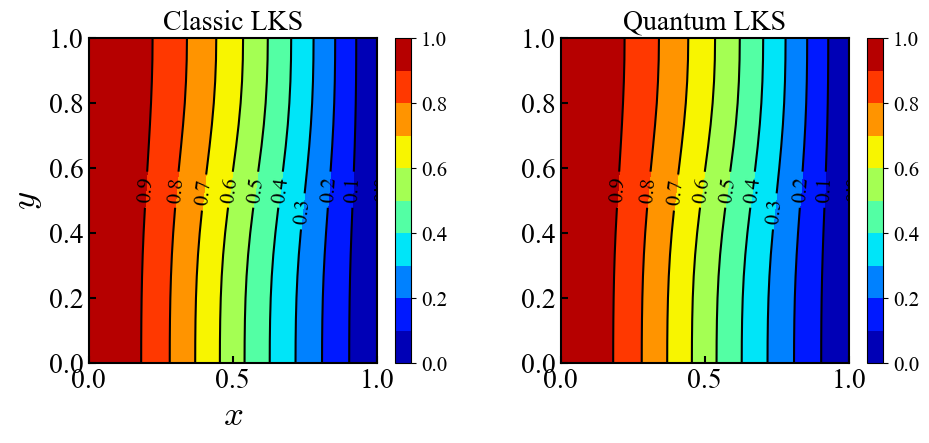

In [8]:
import matplotlib
font = {'family': 'Times New Roman',}
font1 = {'family': 'Times New Roman','style': 'italic',}
matplotlib.rcParams['font.family'] = 'Times New Roman'
matplotlib.rcParams['mathtext.fontset'] = 'cm'

fig = plt.figure(figsize=(20, 5))
ax1 = plt.axes([0.056, 0.2, 0.18, 0.65])
ax01=plt.contourf(X/Lx,Y/Lx,(T-1).T, 11,cmap='jet')
ax001 = plt.colorbar(ax01)
ax001.ax.tick_params(labelsize=15)
CS=plt.contour(X/Lx,Y/Lx,(T-1).T,11,colors='k',linestyles='-',zorder=10)
ax1.clabel(CS, inline=True, fontsize=15)
ax1.set_xlabel('$x$', size = 25,fontdict = font1)
ax1.set_ylabel('$y$', size = 25,fontdict = font1)    
ax1.set_title('Classic LKS', fontsize = 20,fontdict = font)
ax1.tick_params(labelsize=20)
ax=plt.gca()
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
ax.spines['top'].set_linewidth(1.5)
ax1.tick_params(axis="both", which="major", direction="in", width=1.5, length=5)




ax2 = plt.axes([0.292, 0.2, 0.18, 0.65])
ax02=plt.contourf(X/Lx,Y/Lx,(Psi_qlbm3[t + 1, :, :]-1).T, 11,cmap='jet')
ax002 = plt.colorbar(ax02)
ax002.ax.tick_params(labelsize=15)
CS1=plt.contour(X/Lx,Y/Lx,(Psi_qlbm3[t + 1, :, :]-1).T,11,colors='k',linestyles='-',zorder=10)
ax2.clabel(CS1, inline=True, fontsize=15)
ax2.set_title('Quantum LKS', fontsize = 20,fontdict = font)
ax2.tick_params(labelsize=20)
ax=plt.gca()
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
ax.spines['top'].set_linewidth(1.5)
ax2.tick_params(axis="both", which="major", direction="in", width=1.5, length=5)

#plt.savefig('Ra_1000_T.jpg', format='jpg',bbox_inches='tight', dpi=200)
plt.show()



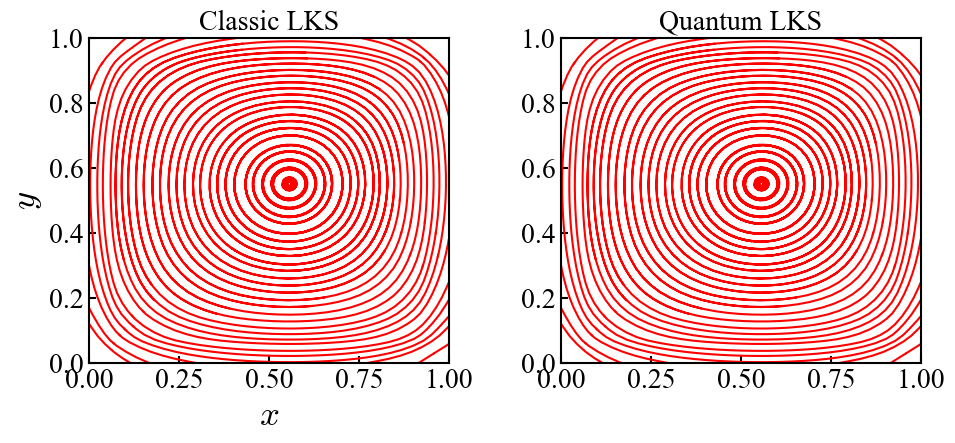

In [9]:
import matplotlib
font = {'family': 'Times New Roman',}
font1 = {'family': 'Times New Roman','style': 'italic',}
matplotlib.rcParams['font.family'] = 'Times New Roman'
matplotlib.rcParams['mathtext.fontset'] = 'cm'

fig = plt.figure(figsize=(20, 5))
ax1 = plt.axes([0.056, 0.2, 0.18, 0.65])
plt.streamplot(X/Lx,Y/Lx,u[:,:,0].T,u[:,:,1].T,density=1,arrowstyle='-',color='r',broken_streamlines=False)
ax1.set_xlabel('$x$', size = 25,fontdict = font1)
ax1.set_ylabel('$y$', size = 25,fontdict = font1)    
ax1.set_title('Classic LKS', fontsize = 20,fontdict = font)
ax1.tick_params(labelsize=20)
ax=plt.gca()
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
ax.spines['top'].set_linewidth(1.5)
ax1.tick_params(axis="both", which="major", direction="in", width=1.5, length=5)




ax2 = plt.axes([0.292, 0.2, 0.18, 0.65])
plt.streamplot(X/Lx,Y/Lx,Psi_qlbm1[t+1,:,:].T,Psi_qlbm2[t+1,:,:].T,density=1,arrowstyle='-',color='r',broken_streamlines=False)
ax2.set_title('Quantum LKS', fontsize = 20,fontdict = font)
ax2.tick_params(labelsize=20)
ax=plt.gca()
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
ax.spines['top'].set_linewidth(1.5)
ax2.tick_params(axis="both", which="major", direction="in", width=1.5, length=5)

#plt.savefig('streamline_1000.jpg', format='jpg',bbox_inches='tight', dpi=200)
plt.show()

